# How Has the UV Index in Germany Developed Since 2000 — and Does It Track Sunburn Hospitalizations?

**LLM note:** the English text in this notebook was done with the help of Claude (Anthropic). The data collection approach, the city/UV-index weighting, and the statistical analysis are the project's own work.

**Research question:** How has the UV Index in Germany developed since 2000, and how does this development compare to trends in UV-related hospitalizations — sunburn (ICD-10 L55) and other effects of heat and light (ICD-10 T67)?

**Data:**
- Hospital cases: Destatis Genesis API, table `23131-0010`, ICD-10 codes L55 and T67, by federal state and year, 2000-2024.
- UV Index: TEMIS clear-sky UV Index (v2.0, 0.25° x 0.25° grid), sampled at the 5 most populous cities per federal state (from GeoNames), 2000-2024. City values are combined into a population-weighted mean UV Index per federal state and year.

**Note on raw data:** the raw TEMIS `.nc` files (~1.5 GB total, one per year) are not included in this repository. They are downloaded automatically by `download_temis()` below on first run.

Part 1 below collects the data; Part 2 analyzes it.

## 1. Data collection

### Step 1 - Imports

In [1]:
import requests
import zipfile
import io
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import xarray as xr
import os


### Step 2 - Hospital data (Destatis)

Queries the Destatis Genesis API for hospital cases with ICD-10 codes L55 (sunburn) and T67 (effects of heat and light), broken down by federal state and year (2000-2024). The response arrives as a zipped CSV, which is unzipped in memory and loaded into a pandas DataFrame.

In [2]:
BASE_URL = "https://genesis.destatis.de/genesisWS/rest/2020/"
TOKEN = "d00644525e694cc9b8a32060046489fb"

headers = {
    'Content-Type': 'application/x-www-form-urlencoded',
    'username': TOKEN,
    'password': ""
}

response = requests.post(BASE_URL + 'data/tablefile',
    headers=headers,
    data={
        'name': '23131-0010',
        'startyear': 2000,
        'endyear': 2024,
        'classifyingvariable1': 'ICD10C',
        'classifyingkey1': 'ICD10-L55,ICD10-T67',
        'format': 'ffcsv',
        'compress': 'false',
        'language': 'de'
    })

# Unzip the response
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open(z.namelist()[0]) as f:
        text = f.read().decode('utf-8-sig')

# Load into pandas and keep only the relevant columns
df = pd.read_csv(io.StringIO(text), delimiter=';')
result = df[['time', '1_variable_attribute_label',
             '2_variable_attribute_code', '2_variable_attribute_label',
             'value']].copy()
result.columns = ['year', 'state', 'icd10_code', 'diagnosis', 'cases']
result['cases'] = pd.to_numeric(result['cases'], errors='coerce')

# Remove the "insgesamt" (sum over all diagnoses) row
result = result[result['icd10_code'].isin(['ICD10-L55', 'ICD10-T67'])]

result.to_csv("sunburn_heatstroke_2000_2024.csv", index=False)

# Totals for Germany per year
pivot_germany = result.pivot_table(index='year', columns='icd10_code',
                                    values='cases', aggfunc='sum', fill_value=0)
print(pivot_germany)

# Broken down by federal state (for comparing against the regional UV index)
pivot_by_state = result.pivot_table(index=['year', 'state'], columns='icd10_code',
                                     values='cases', aggfunc='sum', fill_value=0)
print(pivot_by_state)

icd10_code  ICD10-L55  ICD10-T67
year                            
2000            167.0     1198.0
2001            194.0     1627.0
2002            187.0     1352.0
2003            274.0     2600.0
2004            207.0     1063.0
2005            357.0     1742.0
2006            329.0     2196.0
2007            180.0     1323.0
2008            225.0     1255.0
2009            269.0     1212.0
2010            257.0     1939.0
2011            183.0     1058.0
2012            226.0     1370.0
2013            191.0     1893.0
2014            160.0     1280.0
2015            198.0     2322.0
2016            200.0     1337.0
2017            172.0     1128.0
2018            158.0     1590.0
2019            138.0     1692.0
2020            100.0      719.0
2021            114.0      683.0
2022             92.0      982.0
2023             85.0      830.0
2024             74.0      758.0
icd10_code               ICD10-L55  ICD10-T67
year state                                   
2000 Baden-Württe

### Step 3 - Cities and UV Index data (GeoNames + TEMIS)

To get a regional UV Index per federal state, the 5 most populous cities per federal state are selected from GeoNames, and the TEMIS clear-sky UV Index is sampled at each city's coordinates for every year (2000-2024). The per-city values are then combined into a single population-weighted mean UV Index per federal state and year.

*Running this cell downloads ~1.5 GB of raw `.nc` files from TEMIS (skipped automatically if 
they already exist locally) — this is not included in the repo, see the note above.*

In [3]:
START_YEAR = 2000
END_YEAR = 2024
GEONAMES_ZIP = "cities500.zip"
GEONAMES_TXT = "cities500.txt"

BUNDESLAND_CODES = {
    "01": "Baden-Württemberg", "02": "Bayern", "03": "Bremen", "04": "Hamburg",
    "05": "Hessen", "06": "Niedersachsen", "07": "Nordrhein-Westfalen",
    "08": "Rheinland-Pfalz", "09": "Saarland", "10": "Schleswig-Holstein",
    "11": "Brandenburg", "12": "Mecklenburg-Vorpommern", "13": "Sachsen",
    "14": "Sachsen-Anhalt", "15": "Thüringen", "16": "Berlin",
}

STAEDTE_PRO_BUNDESLAND = 5  # 

# Loads all european cities from GeoNames with over 500 inhabitants
def download_geonames():
    if os.path.exists(GEONAMES_TXT):
        print("GeoNames already exists.")
        return
    url = "https://download.geonames.org/export/dump/cities500.zip"
    response = requests.get(url)
    response.raise_for_status()
    with open(GEONAMES_ZIP, "wb") as file:
        file.write(response.content)
    with zipfile.ZipFile(GEONAMES_ZIP, "r") as zip_ref:
        zip_ref.extractall(path = ".")
    print("GeoNames done.")

# load the cities from GeoNames and filter for German cities, corresponding to the Bundesland_Codes
def load_german_cities():
    columns = ["geonameid", "name", "asciiname", "alternatenames", "latitude", "longitude",
               "feature_class", "feature_code", "country_code", "cc2", "admin1", "admin2",
               "admin3", "admin4", "population", "elevation", "dem", "timezone", "modification_date"]
    df = pd.read_csv(GEONAMES_TXT, sep="\t", names=columns, low_memory=False)

    de_cities = df[df["country_code"] == "DE"].copy()
    de_cities["bundesland"] = de_cities["admin1"].map(BUNDESLAND_CODES)
    de_cities = de_cities.dropna(subset=["bundesland"])

    # sort the german cities by population and select the top 5 cities per federal state
    de_cities = (de_cities.sort_values("population", ascending=False)
                 .groupby("bundesland")
                 .head(STAEDTE_PRO_BUNDESLAND))

    return de_cities[["name", "bundesland", "population", "latitude", "longitude"]]


# Load the TEMIS UV Index date per year
def download_temis(year):
    filename = f"uv_{year}.nc"
    if os.path.exists(filename):
        print(f"TEMIS {year} bereits vorhanden.")
        return filename
    url = f"https://www.temis.nl/uvradiation/v2.0/msr2/nc/{year}/uvief{year}_msr_europe.nc"
    response = requests.get(url)
    response.raise_for_status()
    with open(filename, "wb") as file:
        file.write(response.content)
    return filename


download_geonames()
# Store the German cities in cities
cities = load_german_cities()

# Download the UV Index data for each city per year and calculate the mean UV Index for each city
results = []
for year in range(START_YEAR, END_YEAR + 1):
    filename = download_temis(year)
    ds = xr.open_dataset(filename, group="PRODUCT")

    for index, city in cities.iterrows():
        uv = ds["uvi_clear"].sel(latitude=city["latitude"], longitude=city["longitude"], method="nearest")
        mean_uvi = float(uv.mean(skipna=True).values)

        results.append({
            "city": city["name"],
            "bundesland": city["bundesland"],
            "population": city["population"],
            "year": year,
            "mean_uvi": mean_uvi,
        })

    ds.close()

city_uv = pd.DataFrame(results)
city_uv.to_csv("cities_uv_2000_2024.csv", index=False)

# Calculate the weighted average UV Index for each federal state per year
def gewichteter_durchschnitt(gruppe):
    return (gruppe["mean_uvi"] * gruppe["population"]).sum() / gruppe["population"].sum()

bundesland_uv = (city_uv.groupby(["bundesland", "year"])
                  .apply(gewichteter_durchschnitt)
                  .reset_index(name="mean_uvi"))

bundesland_uv.to_csv("bundesland_uv_2000_2024.csv", index=False)
print(bundesland_uv.head(20))


GeoNames done.
           bundesland  year  mean_uvi
0   Baden-Württemberg  2000  3.802717
1   Baden-Württemberg  2001  3.654516
2   Baden-Württemberg  2002  3.727953
3   Baden-Württemberg  2003  3.735622
4   Baden-Württemberg  2004  3.686530
5   Baden-Württemberg  2005  3.754252
6   Baden-Württemberg  2006  3.712138
7   Baden-Württemberg  2007  3.751500
8   Baden-Württemberg  2008  3.780546
9   Baden-Württemberg  2009  3.771957
10  Baden-Württemberg  2010  3.552126
11  Baden-Württemberg  2011  3.866309
12  Baden-Württemberg  2012  3.830582
13  Baden-Württemberg  2013  3.649124
14  Baden-Württemberg  2014  3.652044
15  Baden-Württemberg  2015  3.699219
16  Baden-Württemberg  2016  3.754795
17  Baden-Württemberg  2017  3.834260
18  Baden-Württemberg  2018  3.742906
19  Baden-Württemberg  2019  3.805794


## 2. Analysis

Loads the two processed datasets (hospital cases and federal-state UV Index) and produces three plots: national hospital case trends for both ICD-10 codes, the UV Index by federal state, and the national population-weighted UV Index trend.

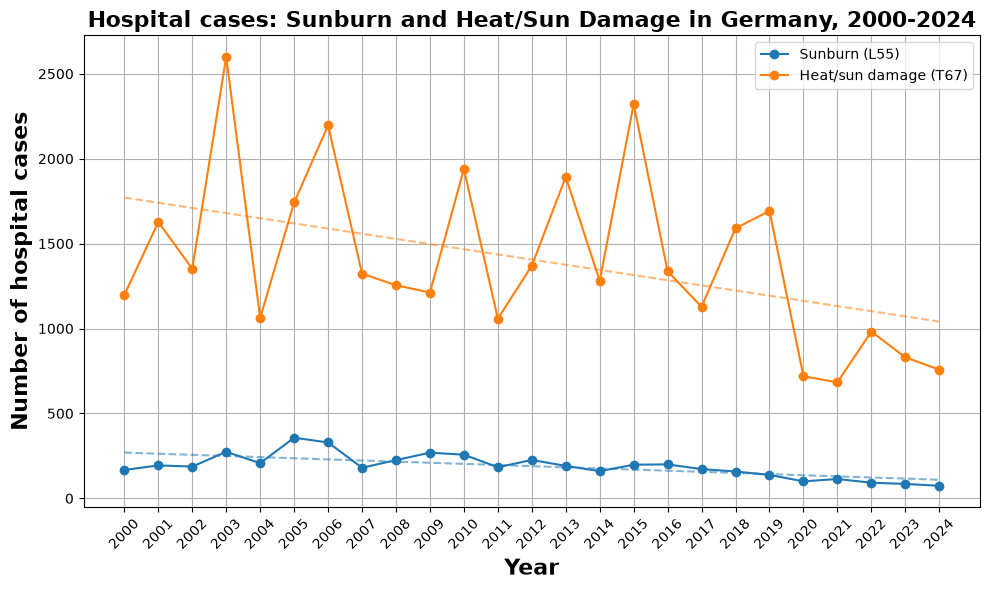

L55: r=-0.69, p=0.0001
T67: r=-0.45, p=0.0257


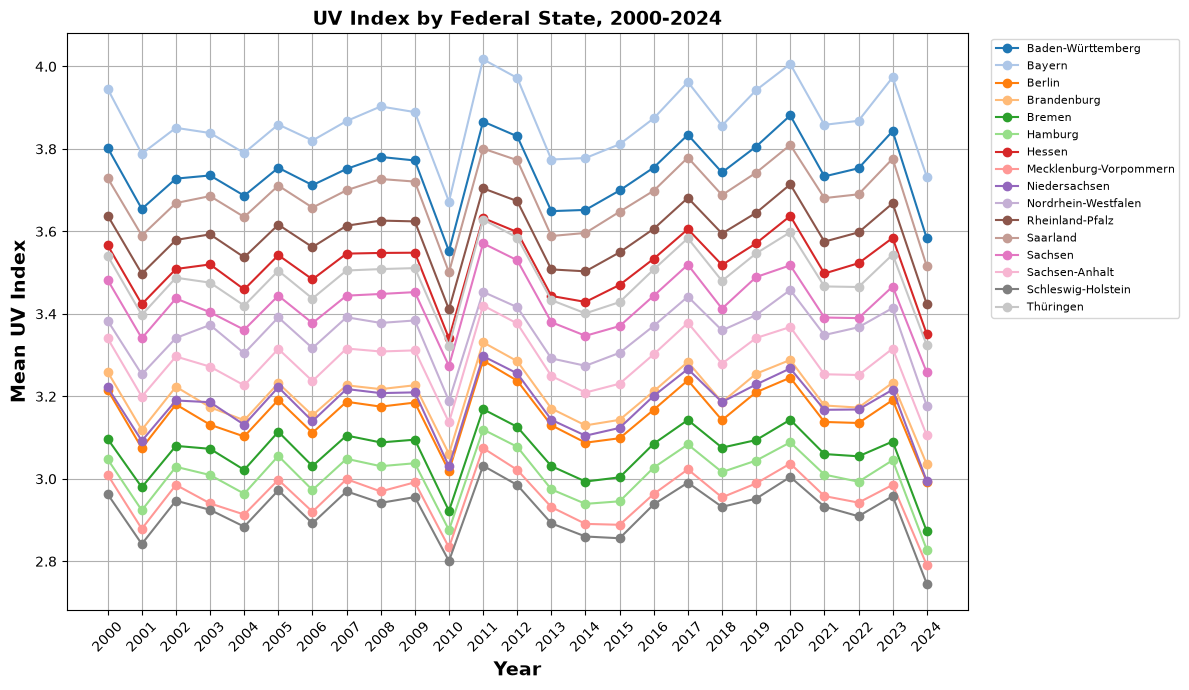

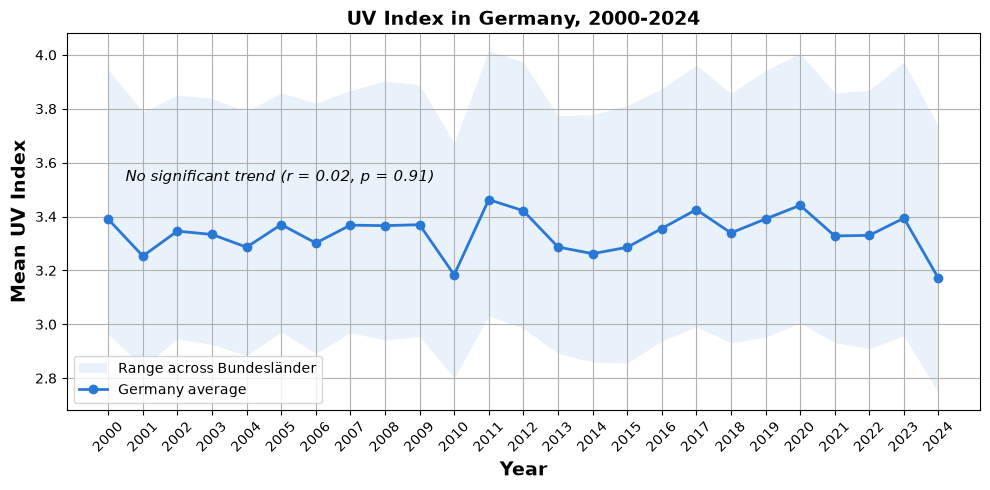

In [4]:
result = pd.read_csv("data_processed/sunburn_heatstroke_2000_2024.csv")
bundesland_uv = pd.read_csv("data_processed/bundesland_uv_2000_2024.csv")

germany_cases = result.groupby(["year", "icd10_code"])["cases"].sum().unstack()

years = germany_cases.index
slope_l, intercept_l, r_l, p_l, _ = stats.linregress(years, germany_cases["ICD10-L55"])
slope_t, intercept_t, r_t, p_t, _ = stats.linregress(years, germany_cases["ICD10-T67"])

# Plot for hospital cases of sunburn and heat/sun damage in Germany
plt.figure(figsize=(10, 6))

plt.plot(years, intercept_l + slope_l * years, color="tab:blue", linewidth=1.5, linestyle="--", alpha=0.55)
plt.plot(years, intercept_t + slope_t * years, color="tab:orange", linewidth=1.5, linestyle="--", alpha=0.55)

plt.plot(years, germany_cases["ICD10-L55"], marker="o", label="Sunburn (L55)")
plt.plot(years, germany_cases["ICD10-T67"], marker="o", label="Heat/sun damage (T67)")
plt.xlabel("Year", fontweight="bold",fontsize=16)
plt.ylabel("Number of hospital cases", fontweight="bold", fontsize=16)
plt.title("Hospital cases: Sunburn and Heat/Sun Damage in Germany, 2000-2024", fontweight="bold", fontsize=16)
plt.xticks(germany_cases.index, rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(f"L55: r={r_l:.2f}, p={p_l:.4f}")
print(f"T67: r={r_t:.2f}, p={p_t:.4f}")

# Federal State-UV-Plot
tab20_colors = plt.cm.tab20.colors

plt.figure(figsize=(12, 7))

for (bundesland, gruppe), color in zip(bundesland_uv.groupby("bundesland"), tab20_colors):
    gruppe = gruppe.sort_values("year")
    plt.plot(gruppe["year"], gruppe["mean_uvi"], marker="o", label=bundesland, color=color)

plt.xlabel("Year", fontweight="bold", fontsize=14)
plt.ylabel("Mean UV Index", fontweight="bold", fontsize=14)
plt.title("UV Index by Federal State, 2000-2024", fontweight="bold", fontsize=14)
plt.xticks(bundesland_uv["year"].unique(), rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid()
plt.tight_layout()
plt.show()

# Germany UV-Index-Plot (Average across federal states)
uv_by_year = bundesland_uv.groupby("year")["mean_uvi"].agg(["mean", "min", "max"])
slope, intercept, r, p, se = stats.linregress(uv_by_year.index, uv_by_year["mean"])

plt.figure(figsize=(10, 5))
plt.fill_between(uv_by_year.index, uv_by_year["min"], uv_by_year["max"],
                  color="#2a78d6", alpha=0.10, linewidth=0, label="Range across Bundesländer")
plt.plot(uv_by_year.index, uv_by_year["mean"], color="#2a78d6", marker="o",
          markersize=6, linewidth=2, label="Germany average")
plt.text(2000.5, uv_by_year["mean"].max() * 1.02,
          f"No significant trend (r = {r:.2f}, p = {p:.2f})", fontsize=11, style="italic")
plt.xlabel("Year", fontweight="bold", fontsize=14)
plt.ylabel("Mean UV Index", fontweight="bold", fontsize=14)
plt.title("UV Index in Germany, 2000-2024", fontweight="bold", fontsize=14)
plt.xticks(uv_by_year.index, rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("uvi_germany_trend.png", dpi=300)
plt.show()